In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from scipy.stats import uniform, loguniform

from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV, train_test_split
from sklearn.metrics import make_scorer, brier_score_loss
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss
from scipy.stats import uniform
import os
import xgboost as xgb


In [28]:
# Assume root directory is './TrainingData'
root_dir = './TrainingData'

TRAIN_list = []
LABELS_list = []
fold_indices = []

SALE_COLUMNS = ["Actual Loss Calculation", "Zero Balance Removal UPB", "Net Sales Proceeds", 
                "Delinquent Accrued Interest", "Expenses", "MI Recoveries", "Non MI Recoveries"]

MISC_COLUMNS_TO_DROP = ["MSA", 'Postal Code',  'Monthly Reporting Period',
                        'Distress Date', 'Default Flag', 'Zero Balance Code', 'Unresolved', 'Last Time Current',
                         'Property State', 'Current Loan Delinquency Status', 'Loan Sequence Number', 'HPI Change %']
CAT_COLUMNS = []

fold = 0 

for year_folder in sorted(os.listdir(root_dir)):
    if not year_folder.startswith("Year"):
        continue
    try:
        year = int(year_folder.replace("Year", ""))
    except ValueError:
        continue
    if year >= 2019:
        continue

    year_path = os.path.join(root_dir, year_folder)
    if os.path.isdir(year_path):
        for file in os.listdir(year_path):
            if file.endswith('.parquet'):
                file_path = os.path.join(year_path, file)
                df = pd.read_parquet(file_path)
                TRAIN_list.append(df.drop(columns=['Major Stress']))
                LABELS_list.append(df['Major Stress'])
                fold_indices.extend([fold] * len(df))
        fold += 1

# Combine everything
TRAIN = pd.concat(TRAIN_list, ignore_index=True).drop(columns=SALE_COLUMNS)
LABELS = pd.concat(LABELS_list, ignore_index=True)


In [29]:
TRAIN = TRAIN.drop(columns=MISC_COLUMNS_TO_DROP)
categorical_cols = TRAIN.select_dtypes(include=['object', 'category']).columns.tolist()

# Use below to add columns that we want dummies for but may not current be dtype categorical
# categorical_cols += CAT_COLUMNS

TRAIN = pd.get_dummies(TRAIN, columns=categorical_cols, drop_first=True)
LABELS = pd.concat(LABELS_list).reset_index(drop=True)
LABELS.fillna(0, inplace=True)

ps = PredefinedSplit(test_fold=fold_indices)

### How to Wrap XGB in a SKL Grid Search CVC
Scorer should be something like Brier Score or F1 (needs to account for the ridiculous imabalance and also should make sure probabilities are well calibrated)

In [30]:
def calibration_errors_adaptive(y_true, y_prob, min_bin_size=200):
    """
    Calculate ECE and MCE with adaptive binning:
    - min_bin_size controls minimum number of samples per bin
    - automatically determines number of bins based on data size
    """
    import numpy as np

    n_samples = len(y_true)
    n_bins = max(1, n_samples // min_bin_size)

    # Edge case: cap at reasonable number of bins
    n_bins = min(n_bins, 20)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1

    ece = 0.0
    mce = 0.0

    for i in range(n_bins):
        bin_mask = binids == i
        bin_size = np.sum(bin_mask)

        if bin_size > 0:
            bin_prob_mean = np.mean(y_prob[bin_mask])
            bin_true_mean = np.mean(y_true[bin_mask])
            error = abs(bin_prob_mean - bin_true_mean)

            ece += (bin_size / n_samples) * error
            mce = max(mce, error)

    return ece, mce

from sklearn.metrics import make_scorer

def ece_scorer(y_true, y_pred_prob):
    ece, _ = calibration_errors_adaptive(y_true, y_pred_prob)
    return -ece  # negate because sklearn expects "higher is better" for scores



In [31]:
from sklearn.model_selection import train_test_split

state = 40

def train_val_test_split(X, y, train_size, val_size, test_size, random_state=None, stratify=None):
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6, "Splits must sum to 1.0"

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify
    )
    
    # Recalculate proportion of train/val within remaining (1 - test)
    val_ratio = val_size / (train_size + val_size)

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio, random_state=random_state, stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_test, X_val, y_train, y_test, y_val = train_val_test_split(
    TRAIN, LABELS,
    train_size=0.45,
    val_size=0.35,
    test_size=0.20,
    random_state=40,
    stratify=LABELS
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}, Validation: {len(X_val)}")




Train: 1883740, Test: 1465132, Validation: 837219


In [13]:
state = 40
# Step 1: Sample 500,000 rows stratified by LABELS
subset_size = 1_000_000
X_sub, _, y_sub, _ = train_test_split(
    TRAIN, LABELS, 
    train_size=subset_size, 
    stratify=LABELS, 
    random_state=state
)

# Step 2: Split into train, early stop, validation (60/20/20 split)
X_train_sub, X_holdout_sub, y_train_sub, y_holdout_sub = train_test_split(
    X_sub, y_sub, test_size=0.4, stratify=y_sub, random_state=state
)
X_early_stop_sub, X_val_sub, y_early_stop_sub, y_val_sub = train_test_split(
    X_holdout_sub, y_holdout_sub, test_size=0.5, stratify=y_holdout_sub, random_state=state
)


In [14]:
NumParamSearchIterations = 15
# Expanded hyperparameter search space
param_distributions = {
    'n_estimators': range(100, 600), 
    'learning_rate': uniform(0.01, 0.03),  
    'max_depth': range(4, 15),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'scale_pos_weight': range(60, 150)  
}

# Setup RandomizedSearchCV
hyperparameter_tuning = RandomizedSearchCV(
    xgb.XGBClassifier(
        random_state=state,
        objective='binary:logistic',
        early_stopping_rounds=20,
        n_jobs = 6,
        tree_method='hist'
    ),
    scoring="neg_brier_score", 
    param_distributions=param_distributions,
    n_iter=NumParamSearchIterations,
    cv=3,
    random_state=state,
    verbose=1,
    n_jobs=1
)

search = hyperparameter_tuning.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_early_stop_sub, y_early_stop_sub)],
    verbose=True
)

# Output best results
print("\nBest Hyperparameters:", search.best_params_)
print("Best Brier Score (negated):", search.best_score_)

# Extract best model
best_model = search.best_estimator_

# Final validation predictions on untouched validation set
y_val_pred_probs = best_model.predict_proba(X_val_sub)[:, 1]

# Standard metrics
ap_score = average_precision_score(y_val_sub, y_val_pred_probs)
brier = brier_score_loss(y_val_sub, y_val_pred_probs)
logloss = log_loss(y_val_sub, y_val_pred_probs)

# New calibration metrics
ece, mce = calibration_errors_adaptive(y_val_sub, y_val_pred_probs)

print("\nValidation Metrics:")
print(f"Average Precision Score: {ap_score:.4f}")
print(f"Brier Score: {brier:.6f}")
print(f"Log Loss: {logloss:.6f}")
print(f"Expected Calibration Error (ECE): {ece:.6f}")
print(f"Maximum Calibration Error (MCE): {mce:.6f}")


Fitting 3 folds for each of 15 candidates, totalling 45 fits
[0]	validation_0-logloss:0.66592
[1]	validation_0-logloss:0.65731
[2]	validation_0-logloss:0.64900
[3]	validation_0-logloss:0.64090
[4]	validation_0-logloss:0.63271
[5]	validation_0-logloss:0.62468
[6]	validation_0-logloss:0.61683
[7]	validation_0-logloss:0.60912
[8]	validation_0-logloss:0.60319
[9]	validation_0-logloss:0.59577
[10]	validation_0-logloss:0.58888
[11]	validation_0-logloss:0.58171
[12]	validation_0-logloss:0.57477
[13]	validation_0-logloss:0.56791
[14]	validation_0-logloss:0.56124
[15]	validation_0-logloss:0.55455
[16]	validation_0-logloss:0.54790
[17]	validation_0-logloss:0.54151
[18]	validation_0-logloss:0.53525
[19]	validation_0-logloss:0.52904
[20]	validation_0-logloss:0.52298
[21]	validation_0-logloss:0.51808
[22]	validation_0-logloss:0.51220
[23]	validation_0-logloss:0.50654
[24]	validation_0-logloss:0.50087
[25]	validation_0-logloss:0.49547
[26]	validation_0-logloss:0.49018
[27]	validation_0-logloss:0.484

KeyboardInterrupt: 

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    'y_true': y_val_sub,
    'y_pred_prob': y_val_pred_probs
})

# Define probability bins
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', 
          '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
results_df['prob_bin'] = pd.cut(results_df['y_pred_prob'], bins=bins, labels=labels, include_lowest=True)

# Group by bins
bin_summary = results_df.groupby('prob_bin').agg(
    samples=('y_true', 'count'),
    percent=('y_true', lambda x: len(x) / len(results_df) * 100),
    distress_rate=('y_true', 'mean')
).reset_index()


print(bin_summary)


In [25]:
import pandas as pd

# Pull feature importance scores
booster = model.get_booster()
importance_dict = booster.get_score(importance_type='gain')

# Convert to DataFrame for easy viewing
importance_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Importance (Gain)': list(importance_dict.values())
}).sort_values(by='Importance (Gain)', ascending=False)

print(importance_df)


                                   Feature  Importance (Gain)
17                     Numeric Delinquency        1635.416870
8                       Original Loan Term         464.030487
18                     MaxPriorDelinquency         245.146576
9                      Number of Borrowers         179.269455
16                    Interest Bearing UPB         123.768524
7                   Original Interest Rate         122.916222
6             Original Loan-to-Value (LTV)         119.997276
19               Current Unemployment Rate         119.764236
0                             Credit Score         116.522408
32                          Loan Purpose_P         115.768532
11                                Loan Age         110.245636
13                       Modification Flag         108.317307
12      Remaining Months to Legal Maturity          94.920715
3   Original Combined Loan-to-Value (CLTV)          89.415085
26                        Property Type_CO          86.271545
21      

## Ensemble

In [32]:
# Best Hyper Params
best_params = {
               'colsample_bytree': 0.9872197327257972, 
               'learning_rate': 0.046666662536206674, 
               'max_depth': 11, 
               'n_estimators': 300, 
               'scale_pos_weight': 95, 
               'subsample': 0.9286871422830952,
               'n_jobs': 6
               }


model = xgb.XGBClassifier(**best_params, random_state=42)
model.fit(
    X_train, y_train,
    verbose=2
)

preds_val = model.predict_proba(X_val)[:, 1]


# Evaluate ensemble
ap_score = average_precision_score(y_val, preds_val)
brier = brier_score_loss(y_val, preds_val)
logloss = log_loss(y_val, preds_val)
ece, mce = calibration_errors_adaptive(y_val, preds_val)


print("\nEnsemble Validation Metrics:")
print(f"Average Precision Score: {ap_score:.4f}")
print(f"Brier Score: {brier:.6f}")
print(f"Log Loss: {logloss:.6f}")
print(f"Expected Calibration Error (ECE): {ece:.6f}")
print(f"Maximum Calibration Error (MCE): {mce:.6f}")


Ensemble Validation Metrics:
Average Precision Score: 0.4293
Brier Score: 0.029569
Log Loss: 0.108719
Expected Calibration Error (ECE): 0.069143
Maximum Calibration Error (MCE): 0.705642


In [19]:
import os

# Create folder if it doesn't exist
os.makedirs("ensemble_models", exist_ok=True)

# Save the model in native XGBoost format
model.get_booster().save_model(f"ensemble_models/best_model.xgb")

print("Ensemble model saved in native XGBoost format.")



Ensemble model saved in native XGBoost format.


c:\Users\seanv\Anaconda3_old\envs\gpt-env\lib\site-packages\xgboost\core.py:158: UserWarning: [14:26:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


In [16]:
# Calibration evaluation
results_df = pd.DataFrame({
    'y_true': y_val,
    'y_pred_prob': preds_val
})

# Define probability bins
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', 
          '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
results_df['prob_bin'] = pd.cut(results_df['y_pred_prob'], bins=bins, labels=labels, include_lowest=True)

# Group by bins
bin_summary = results_df.groupby('prob_bin').agg(
    samples=('y_true', 'count'),
    percent=('y_true', lambda x: len(x) / len(results_df) * 100),
    distress_rate=('y_true', 'mean')
).reset_index()

print("\nCalibration Summary by Probability Bin:")
print(bin_summary)



Calibration Summary by Probability Bin:
  prob_bin  samples    percent  distress_rate
0    0-0.1   747284  89.257888       0.001931
1  0.1-0.2    36812   4.396938       0.015593
2  0.2-0.3    17294   2.065648       0.024633
3  0.3-0.4    10465   1.249972       0.033063
4  0.4-0.5     7096   0.847568       0.041432
5  0.5-0.6     5010   0.598410       0.058683
6  0.6-0.7     3741   0.446836       0.089548
7  0.7-0.8     2784   0.332529       0.135417
8  0.8-0.9     2339   0.279377       0.218042
9  0.9-1.0     4394   0.524833       0.606736


C:\Users\seanv\AppData\Local\Temp\ipykernel_5124\988948513.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = results_df.groupby('prob_bin').agg(


In [8]:
df = pd.DataFrame({
    'y_true': y_val,
    'y_prob': preds_val
})
df['prob_bin'] = pd.qcut(df['y_prob'], q=1000, labels=False)

# Group by bin and calculate average predicted probability and actual event rate
calibration_df = df.groupby('prob_bin').agg(
    avg_predicted_prob=('y_prob', 'mean'),
    actual_rate=('y_true', 'mean'),
    count=('y_true', 'count')
).reset_index()

# Optional: round values for cleaner display
calibration_df = calibration_df.round(4)

In [9]:
calibration_df

,prob_bin,avg_predicted_prob,actual_rate,count
0,0,0.0000,0.0000,838
1,1,0.0000,0.0000,837
2,2,0.0000,0.0000,837
3,3,0.0000,0.0000,837
4,4,0.0000,0.0000,838
...,...,...,...,...
995,995,0.9263,0.3520,838
996,996,0.9582,0.4707,837
997,997,0.9815,0.6177,837
998,998,0.9938,0.7873,837


In [33]:
def compute_empirical_monotonic_bins(y_true, y_scores, init_bins=1000):
    """
    1) Bin y_scores into init_bins quantiles (dropping empty bins)
    2) Compute empirical P(y=1) in each bin
    3) Merge adjacent bins until the sequence of P(y=1) is non-decreasing
    Returns:
      intervals: list of (lower_edge, upper_edge)
      probs:      list of empirical P(y=1) for each interval
      counts:     list of sample counts per interval
    """
    # Step 1: initial quantile bins
    # retbins: array of length n_bins+1
    _, retbins = pd.qcut(
        y_scores, q=init_bins, duplicates="drop", retbins=True
    )
    # assign each score to bin index
    bin_idx = np.digitize(y_scores, retbins) - 1
    # clamp
    bin_idx = np.clip(bin_idx, 0, len(retbins) - 2)
    
    # Step 2: build initial stats per bin
    df = pd.DataFrame({"bin": bin_idx, "y": y_true})
    stats = (
        df
        .groupby("bin")["y"]
        .agg(count="size", rate="mean")
        .reset_index()
        .sort_values("bin")
        .reset_index(drop=True)
    )
    # capture edges
    edges = [(retbins[i], retbins[i+1]) for i in stats["bin"]]
    
    # Step 3: merge to enforce non-decreasing rate
    merged = []
    for (low, high), row in zip(edges, stats.itertuples()):
        merged.append({
            "low": low,
            "high": high,
            "count": row.count,
            "rate": row.rate
        })
    i = 0
    while i < len(merged) - 1:
        if merged[i]["rate"] > merged[i+1]["rate"]:
            # merge i and i+1
            c0, r0 = merged[i]["count"], merged[i]["rate"]
            c1, r1 = merged[i+1]["count"], merged[i+1]["rate"]
            new_count = c0 + c1
            new_rate  = (c0*r0 + c1*r1) / new_count
            merged[i] = {
                "low": merged[i]["low"],
                "high": merged[i+1]["high"],
                "count": new_count,
                "rate": new_rate
            }
            merged.pop(i+1)
            # step back one to re-check monotonicity
            i = max(i-1, 0)
        else:
            i += 1
    
    # extract outputs
    intervals = [(m["low"], m["high"]) for m in merged]
    probs     = [m["rate"]     for m in merged]
    counts    = [m["count"]    for m in merged]
    return intervals, probs, counts

def apply_empirical_calibration(y_scores, intervals, probs):
    """
    Vectorized mapping from raw y_scores → calibrated probs
    intervals : list of (low, high)
    probs     : list of empirical P(y=1) per interval
    """
    y_scores = np.asarray(y_scores)
    calibrated = np.zeros_like(y_scores, dtype=float)
    for (low, high), p in zip(intervals, probs):
        mask = (y_scores >= low) & (y_scores <= high)
        calibrated[mask] = p
    return calibrated

# ------------------------------
# USAGE EXAMPLE (after training):
# ------------------------------

# 2) Compute monotonic empirical bins on (y_val, preds_val)
intervals, bin_probs, bin_counts = compute_empirical_monotonic_bins(
    y_true=y_val.values,
    y_scores=preds_val,
    init_bins=1000
)

# 3) Evaluate on X_val itself (sanity check)
calibrated_val = apply_empirical_calibration(preds_val, intervals, bin_probs)
print("VAL metrics:",
      "AP", average_precision_score(y_val, calibrated_val),
      "Brier", brier_score_loss(y_val, calibrated_val),
      "LogLoss", log_loss(y_val, calibrated_val))


VAL metrics: AP 0.4129298379432451 Brier 0.006169459186122651 LogLoss 0.02845608215686816


In [38]:
# 4) On X_test:
preds_test = model.predict_proba(X_test)[:,1]
calibrated_test = apply_empirical_calibration(preds_test, intervals, bin_probs)

# 5) Final evaluation on held-out test
print("TEST metrics:",
      "AP", average_precision_score(y_test, calibrated_test),
      "Brier", brier_score_loss(y_test, calibrated_test),
      "LogLoss", log_loss(y_test, calibrated_test))

# 6) Bin summary DataFrame on test set
df_test = pd.DataFrame({
    "score": preds_test,
    "calibrated_prob": calibrated_test,
    "y_true": y_test.values
})
df_test["bin"] = np.digitize(preds_test, [low for low,_ in intervals]) - 1
df_test["bin"] = df_test["bin"].clip(0, len(intervals)-1)
bin_summary = (
    df_test
    .groupby("bin")
    .agg(
        lower_score     = ("score",           "min"),
        upper_score     = ("score",           "max"),
        avg_score       = ("score",           "mean"),
        avg_calibrated  = ("calibrated_prob", "mean"),
        actual_rate     = ("y_true",          "mean"),
        count           = ("y_true",          "size")
    )
    .reset_index(drop=True)
    .round(6)
)
print(bin_summary)


TEST metrics: AP 0.4113192747999843 Brier 0.0061744673341207305 LogLoss 0.028520760809995778
    lower_score  upper_score  avg_score  avg_calibrated  actual_rate  count
0      0.000008     0.000049   0.000038        0.000000     0.000000   1552
1      0.000050     0.000062   0.000056        0.000000     0.000000   1494
2      0.000062     0.000071   0.000067        0.000000     0.000000   1517
3      0.000071     0.000079   0.000075        0.000000     0.000000   1473
4      0.000079     0.000086   0.000083        0.000000     0.000000   1473
..          ...          ...        ...             ...          ...    ...
72     0.947006     0.964867   0.955930        0.359189     0.353591   1448
73     0.964887     0.981122   0.973248        0.475508     0.466325   1559
74     0.981139     0.991954   0.987209        0.602151     0.624753   1519
75     0.991957     0.996800   0.994679        0.776583     0.756246   1481
76     0.996801     0.999775   0.998209        0.902136     0.887925   

In [35]:
# Build test-set calibration DataFrame
df_test = pd.DataFrame({
    'y_true': y_test,
    'y_prob': calibrated_test   # or use preds_test if you want to bin raw scores instead
})

# Choose number of quantile bins
n_q = 1000

# Assign each test sample to a quantile bin
df_test['prob_bin'] = pd.qcut(
    df_test['y_prob'],
    q=n_q,
    labels=False,
    duplicates='drop'
)

# Aggregate per‐bin stats
calibration_df_test = (
    df_test
    .groupby('prob_bin')
    .agg(
        avg_predicted_prob=('y_prob', 'mean'),
        actual_rate         =('y_true', 'mean'),
        count               =('y_true', 'count')
    )
    .reset_index()
    .round(4)
)


In [13]:
calibration_df_test


,prob_bin,avg_predicted_prob,actual_rate,count
0,0,0.0000,0.0001,203566
1,1,0.0003,0.0003,134518
2,2,0.0005,0.0004,28419
3,3,0.0005,0.0006,19430
4,4,0.0007,0.0006,51744
...,...,...,...,...
58,58,0.3313,0.3278,1150
59,59,0.4858,0.4910,2214
60,60,0.7074,0.6772,1081
61,61,0.8111,0.7891,1176


In [23]:
import json

def save_thresholds(intervals, probs, output_path):
    """
    Save empirical calibration bin thresholds and probabilities to JSON.

    Args:
        intervals: list of (low, high) tuples
        probs: list of probabilities for each bin
        output_path: file path to save JSON
    """
    to_save = [
        {'low': float(low), 'high': float(high), 'p': float(p)}
        for (low, high), p in zip(intervals, probs)
    ]
    with open(output_path, 'w') as f:
        json.dump(to_save, f, indent=2)


In [ ]:
save_thresholds(intervals, bin_probs, 'calibration_thresholds.json')


C:\Users\seanv\AppData\Local\Temp\ipykernel_21704\291054325.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('fixed_bin')


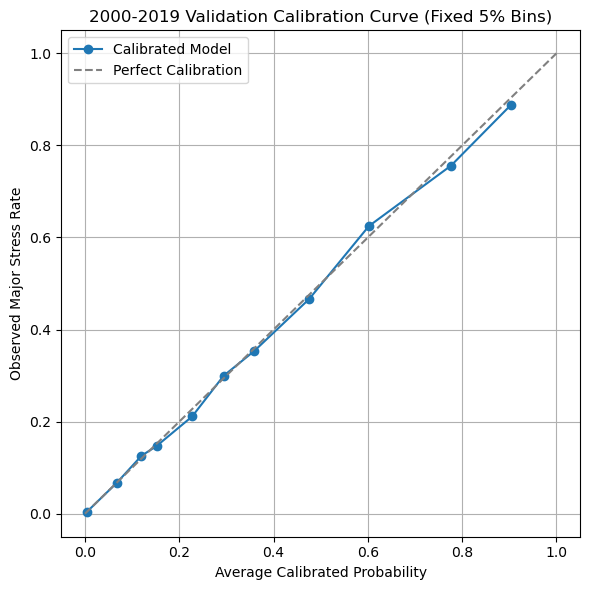

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Define the fixed 5% bins from 0% to 100%
bin_edges = np.arange(0.0, 1.05, 0.05)
bin_labels = [f"{int(left*100)}–{int(right*100)}%" 
              for left, right in zip(bin_edges[:-1], bin_edges[1:])]

# 2) Cut the calibrated probabilities into those bins
df_test['fixed_bin'] = pd.cut(
    df_test['calibrated_prob'],
    bins=bin_edges,
    include_lowest=True,
    right=False,
    labels=bin_labels
)

# 3) Summarize each bin
fixed_summary = (
    df_test
    .groupby('fixed_bin')
    .agg(
        avg_calibrated_prob=('calibrated_prob', 'mean'),
        actual_rate=('y_true', 'mean'),
        count=('y_true', 'size')
    )
    .dropna(subset=['avg_calibrated_prob'])  # drop empty bins
    .reset_index()
)

# 4) Plot the calibration curve
plt.figure(figsize=(6,6))
plt.plot(
    fixed_summary['avg_calibrated_prob'],
    fixed_summary['actual_rate'],
    '-o',
    label='Calibrated Model'
)
plt.plot([0,1], [0,1], '--', color='gray', label='Perfect Calibration')
plt.xlabel("Average Calibrated Probability")
plt.ylabel("Observed Major Stress Rate")
plt.title("2000-2019 Validation Calibration Curve (Fixed 5% Bins)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("Charts/valstress2000_2019.png")


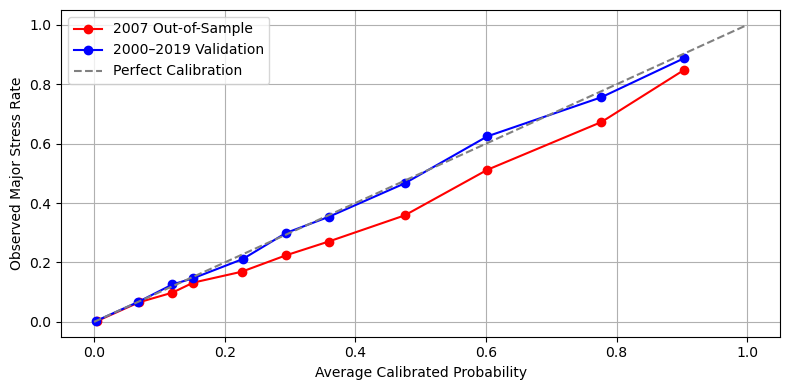

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# 2007 out-of-sample calibration summary
data_2007 = {
    'fixed_bin': [
        "0–5%", "5–10%", "10–15%", "15–20%", "20–25%", "25–30%",
        "35–40%", "45–50%", "60–65%", "75–80%", "90–95%"
    ],
    'avg_calibrated_prob': [
        0.003736, 0.068917, 0.119933, 0.151732, 0.225962, 0.293907,
        0.359189, 0.475508, 0.602151, 0.776583, 0.903341
    ],
    'actual_rate': [
        0.002012, 0.066065, 0.098422, 0.132121, 0.168831, 0.224189,
        0.270538, 0.358543, 0.512195, 0.672757, 0.848485
    ]
}
df_2007 = pd.DataFrame(data_2007)

# 2000–2019 validation calibration summary
data_val = {
    'fixed_bin': [
        "0–5%", "5–10%", "10–15%", "15–20%", "20–25%", "25–30%",
        "35–40%", "45–50%", "60–65%", "75–80%", "90–95%"
    ],
    'avg_calibrated_prob': [
        0.003585, 0.067810, 0.119888, 0.151732, 0.227356, 0.293907,
        0.359189, 0.475508, 0.602151, 0.776583, 0.903341
    ],
    'actual_rate': [
        0.003550, 0.067429, 0.125853, 0.146913, 0.211234, 0.299389,
        0.353591, 0.466325, 0.624753, 0.756246, 0.887776
    ]
}
df_val = pd.DataFrame(data_val)

# Sort by avg_calibrated_prob to ensure the lines connect in order
df_2007 = df_2007.sort_values('avg_calibrated_prob')
df_val = df_val.sort_values('avg_calibrated_prob')

# Plot both curves on the same figure
plt.figure(figsize=(8, 4))

plt.plot(
    df_2007['avg_calibrated_prob'],
    df_2007['actual_rate'],
    '-o', color='red', label='2007 Out-of-Sample'
)

plt.plot(
    df_val['avg_calibrated_prob'],
    df_val['actual_rate'],
    '-o', color='blue', label='2000–2019 Validation'
)

# Perfect calibration line
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect Calibration')

plt.xlabel("Average Calibrated Probability")
plt.ylabel("Observed Major Stress Rate")
# plt.title("Calibration Curves: Validation vs. 2007 Out-of-Sample")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Charts/stresscalibration.png")
